In [10]:
from numpy import reshape
from constants import *
from ml_func import *
from functions import *
from rotation_func import *
from packages import *
from class_sys_info import *

#Current working directory
cwd = os.getcwd()
cwd = cwd[:-9]+'tests/main_test/'
print(f'Start Importing Files from {cwd}')

train_rot = False
train_set = True

MSE_list = []
#Gathering all directories of all molecular systems 
mol_sys_dirs = sorted(os.listdir(cwd))
train_set_fraction = [None]# np.linspace(0.2,0.99,8)
#For every molecular system
for rnd_state in [46]:#,42,0,56,29,100,208,46,30,39]:
    for train in train_set_fraction:
        Systems = []
        mol_sys_idx = []
        for mol in range(len(mol_sys_dirs)):
            #Gathering for each molecular systems all directories of diffrent structures
            mol_dir = f'{cwd}/{mol_sys_dirs[mol]}/'
            struc_sys_dirs = sorted([ name for name in os.listdir(mol_dir) if os.path.isdir(os.path.join(mol_dir, name)) ])
            #print(f'Molecule No. {mol}')
            if mol_sys_dirs[mol] == 'H3':
                test_mol = mol
            #For every structure of every molecular system
            for sys in range(len(struc_sys_dirs)):
                #print(f'System {struc_sys_dirs[sys]}')

                system = sys_info(folder=f'{mol_dir}{struc_sys_dirs[sys]}/init_coord/',molecule=mol,variation=sys)

                system.rot_init_inert()

                system.rot_inert_apf()

                mol_sys_idx.append([mol,sys])

                Systems.append(system)

Start Importing Files from /home/gfeldmann/Documents/GitLab/hessian_ml/tests/main_test/
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
1 1
0 0
0 1
0 2
1 1
1 2
2 2
0 0
0 1
0 2
1 1
1 2
2 2
0 0
0 1
0 2
1 1
1 2
2 2
0 0
0 1
0 2
1 1
1 2
2 2
0 0
0 1
0 2
1 1
1 2
2 2
0 0
0 1
0 2
1 1
1 2
2 2
0 0
0 1
0 2
1 1
1 2
2 2
0 0
0 1
0 2
1 1
1 2
2 2
0 0
0 1
0 2
1 1
1 2
2 2
0 0
0 1
0 2
1 1
1 2
2 2
0 0
0 1
0 2
1 1
1 2
2 2
0 0
0 1
0 2
1 1
1 2
2 2
0 0
0 1
0 2
1 1
1 2
2 2
0 0
0 1
0 2
1 1
1 2
2 2
0 0
0 1
0 2
1 1
1 2
2 2
0 0
0 1
0 2
1 1
1 2
2 2


ValueError: could not convert string to float: 'O'

Fitting the Model.
Testing the Model.
0.0028740432041179254


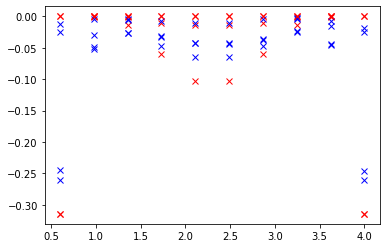

[[ 5.71772210e-03  3.24000000e-08 -2.16000000e-08]
 [ 3.29000000e-08 -6.00308200e-04  1.38385088e-24]
 [-2.20000000e-08  1.27363267e-24 -6.00308200e-04]]
[[ 5.71772210e-03  3.29000000e-08 -2.20000000e-08]
 [ 3.24000000e-08 -6.00308200e-04  1.27363267e-24]
 [-2.16000000e-08  1.38385088e-24 -6.00308200e-04]]
R2(homo)   :0.891
R2(hetero)   :0.959
MSE(homo)  :0.002
MSE(hetero):0.0


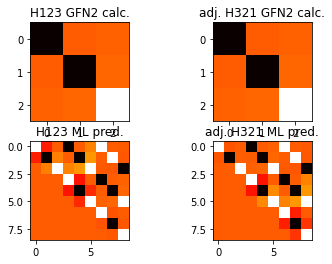

In [2]:
        print('Fitting the Model.')
        rnd_state = None

        test_idx = []
        train_idx = []
        for i in range(len(mol_sys_idx)):
            if mol_sys_idx[i][0] == test_mol:
                test_idx.append(i)
            else:
                train_idx.append(i)

        #test_size = 1 - train
        #train_size = train
        #print(f'Train size:{train_size}')
        #train_idx, temp = train_test_split(train_idx,test_size=test_size,train_size=train_size,random_state=rnd_state)
            
        test_train_split_idx = np.arange(0,len(mol_sys_idx),1)
        #train_idx, test_idx = train_test_split(test_train_split_idx,test_size=0.25,train_size=0.75,random_state=rnd_state)

        
        X_homo = []
        y_homo = []

        X_hetero = []
        y_hetero = []

        for i in train_idx:

            Systems[i].gen_Hessian_vector(train_rot=train_rot,train_set =train_set)
            X_homo_temp,X_hetero_temp = Systems[i].gen_Feature(label = 'indexed',train_rot=train_rot,train_set =train_set)

            X_homo.extend(X_homo_temp)
            y_homo.extend(Systems[i].H_AA_vec)

            X_hetero.extend(X_hetero_temp)
            y_hetero.extend(Systems[i].H_AB_vec)

        regr_homonuclear=  ExtraTreesRegressor(n_estimators = 500,random_state=rnd_state,bootstrap=False) 
        regr_heteronuclear = ExtraTreesRegressor(n_estimators = 500,random_state=rnd_state,bootstrap=False)

        #regr_homonuclear = KNeighborsRegressor(n_neighbors=10, weights='distance' )
        #regr_heteronuclear = KNeighborsRegressor(n_neighbors=10, weights='distance' )

        regr_homonuclear.fit(X_homo,y_homo)
        regr_heteronuclear.fit(X_hetero,y_hetero)

        full_y_pred_homo = []
        full_y_pred_hetero = []

        full_X_homo_test = []
        full_X_hetero_test = []

        full_y_test_homo = []
        full_y_test_hetero = []

        test_symmetry_homo = []
        test_symmetry_hetero = []

        print('Testing the Model.')
        lambd = [[],[]]
        test_sys = None

        for i in test_idx:
            Systems[i].gen_Hessian_vector()
            X_homo_temp,X_hetero_temp = Systems[i].gen_Feature(label = 'indexed')
        
            # if i == test_idx[0]:
            #     print(X_homo_temp[0])
            full_X_homo_test.extend(X_homo_temp)
            full_X_hetero_test.extend(X_hetero_temp)

            full_y_test_homo.extend(Systems[i].H_AA_vec)
            full_y_test_hetero.extend(Systems[i].H_AB_vec)

            y_homo_pred = regr_homonuclear.predict(X_homo_temp)
            y_hetero_pred = regr_heteronuclear.predict(X_hetero_temp)
            #y_hetero_pred

            Systems[i].get_pred_hessian(hessian_homo=y_homo_pred,hessian_hetero=y_hetero_pred)

            full_y_pred_homo.extend(y_homo_pred)
            full_y_pred_hetero.extend(y_hetero_pred)

            test_symmetry_homo.append(np.array(sorted(y_homo_pred)))
            test_symmetry_hetero.append(np.array(sorted(y_hetero_pred)))

            #Systems[i].project_hessian(label='xTB')
            #Systems[i].project_hessian(label='pred')

            #Systems[i].weight_hessian(label='xTB')
            #Systems[i].weight_hessian(label='pred')

            Systems[i].gen_eigenvalues()
            lambd[0].append(sorted(Systems[i].hessian_lambd))
            lambd[1].append(sorted(Systems[i].H_pred_lambd))

        length = np.linspace(0.6,4,10)
        for i in range(len(length)):
            for j in range(4):
                plt.plot(length[i],lambd[1][i][j],'bx')
                plt.plot(length[i],lambd[0][i][j],'rx')
        
        MSE = 0 
        for i in range(5):
            for j in range(4):
                MSE += 1/(5*4) * np.abs(lambd[1][i][j] - lambd[1][-(1+i)][j])

        print(MSE)
        MSE_list.append(MSE)
        plt.show()
        #eigh_H_pred3 = Systems[test_idx[3]].H_pred_lambd
        #eigh_H_pred6 = Systems[test_idx[6]].H_pred_lambd

        #Systems[test_idx[3]].perm_Hess(0,2)
        #Systems[test_idx[3]].gen_eigenvalues()
        #eigh_H_pred_perm3 = Systems[test_idx[3]].H_pred_lambd

        #Systems[test_idx[6]].perm_Hess(0,2)
        #Systems[test_idx[6]].gen_eigenvalues()
        #eigh_H_pred_perm6 = Systems[test_idx[6]].H_pred_lambd

        #print(eigh_H_pred3)
        #print(eigh_H_pred_perm3)

        #print(eigh_H_pred6)
        #print(eigh_H_pred_perm6)
        #print(Systems[test_idx[3]].xyz)
        #print(Systems[test_idx[6]].xyz)

        #Systems[test_idx[1]].rot_init_inert()
        #Systems[test_idx[8]].rot_init_inert()
        #print(Systems[test_idx[3]].features.Feature_AA[0:1])

        #print(regr_homonuclear.predict(Systems[test_idx[3]].features.Feature_AA[0:1]))  
        #print(regr_homonuclear.predict(Systems[test_idx[6]].features.Feature_AA[18:19]))
        mat2 = np.array(Systems[test_idx[2]].H_APF_mat)[3:6,6:9]
        R2 = np.array(Systems[test_idx[2]].R_MI_APF_mat)[3:6,6:9]

        mat7 = np.array(Systems[test_idx[7]].H_APF_mat)[0:3,3:6]
        R7 = np.array(Systems[test_idx[7]].R_MI_APF_mat)[0:3,3:6]

        c2 = matmul(matmul((R2),mat2),np.transpose(R2))
        c7 = matmul(matmul((R7),mat7),np.transpose(R7))

        print(c2)
        print(c7)

        #mat2 = np.array(Systems[test_idx[7]].H_APF_mat)
     
        Systems[test_idx[2]].perm_Hess(0,2)
        Systems[test_idx[7]].perm_Hess(0,2)

        mat3 = np.array(Systems[test_idx[2]].H_APF_mat)
        mat4 = np.array(Systems[test_idx[7]].H_APF_mat)
        mat22 = np.zeros([9,9])
        mat44 = np.zeros([9,9])
        
        ''' 
        for i in range(0,7,3):
            for j in range(0,7,3):          
                R = rot_Z(0)
                mat44[(6-i):(6-i)+3,(6-j):(6-j)+3] = matmul(matmul((R),mat4[i:i+3,j:j+3]),np.transpose(R))
                mat22[(6-i):(6-i)+3,(6-j):(6-j)+3] = matmul(matmul((R),mat2[i:i+3,j:j+3]),np.transpose(R))
        '''
        
        fig,axs = plt.subplots(2,2)
        vminmax = 1e-6

        axs[0,0].imshow(mat2, cmap='hot', interpolation='nearest', vmin=-vminmax, vmax=vminmax)
        axs[0,0].set_title('H123 GFN2 calc.')
        axs[0,1].imshow(mat7, cmap='hot', interpolation='nearest', vmin=-vminmax, vmax=vminmax)
        axs[0,1].set_title('adj. H321 GFN2 calc.')
        axs[1,0].imshow(mat3, cmap='hot', interpolation='nearest', vmin=-vminmax, vmax=vminmax)
        axs[1,0].set_title('H123 ML pred.')
        axs[1,1].imshow(mat4, cmap='hot', interpolation='nearest', vmin=-vminmax, vmax=vminmax)
        axs[1,1].set_title('adj. H321 ML pred.')
        #axs[0,2].imshow(mat1-mat22, cmap='hot', interpolation='nearest', vmin=-vminmax, vmax=vminmax)
        #axs[0,2].set_title('Difference GFN2')
        #axs[1,2].imshow(mat3-mat44, cmap='hot', interpolation='nearest', vmin=-vminmax, vmax=vminmax)
        #axs[1,2].set_title('Difference ML pred.')

        #print(Systems[test_idx[1]].features.qm_atom[:])
        #print(Systems[test_idx[8]].features.qm_atom[:])
        #print(Systems[test_idx[2]].R_MI_APF_mat-Systems[test_idx[7]].R_MI_APF_mat)



        r_score_homo = regr_homonuclear.score(full_X_homo_test,full_y_test_homo)
        r_score_hetero = regr_heteronuclear.score(full_X_hetero_test,full_y_test_hetero)

        MSE_homonuclear  = mean_squared_error(full_y_test_homo,full_y_pred_homo)
        MSE_heteronuclear  = mean_squared_error(full_y_test_hetero,full_y_pred_hetero)

        print(f'R2(homo)   :{round(r_score_homo,3)}')
        print(f'R2(hetero)   :{round(r_score_hetero,3)}')

        print(f'MSE(homo)  :{round(MSE_homonuclear,3)}')
        print(f'MSE(hetero):{round(MSE_heteronuclear,3)}')
        '''

        #plt.xlabel(r'$x$(H2) [$\mathrm{\AA}$]',fontsize=24)
        #plt.ylabel(r'$k~[\mathrm{N~\mathrm{m}^{-1}}]$',fontsize=24)  
        '''

        #plt.savefig(f'plots/lambda_symmetry_check{time_atm}.png')
        #plt.savefig(f'plots/lambda_symmetry_check{time_atm}.svg')

        plt.show()

np.savetxt('MSE_list.txt',MSE_list)

In [4]:
print(Systems[test_idx[2]].xyz)
print(Systems[test_idx[7]].xyz)

print(inert_tensor(Systems[test_idx[7]].xyz))

for i in range(9):
    print(Systems[test_idx[2]].features.Feature_AB[i+9][0])
    print(Systems[test_idx[2]].H_AA_vec[i+9])

    print(Systems[test_idx[7]].features.Feature_AB[9+i][0])
    print(Systems[test_idx[7]].H_AA_vec[i+9])

  atoms         x    y    z
0     H -1.740741  0.0  0.0
1     H -0.518519  0.0  0.0
2     H  2.259259  0.0  0.0
  atoms         x    y    z
0     H -2.259259  0.0  0.0
1     H  0.518519  0.0  0.0
2     H  1.740741  0.0  0.0
(array([[ 0.        ,  0.        ,  0.        ],
       [ 0.        , 10.00290039,  0.        ],
       [ 0.        ,  0.        , 10.00290039]]),   atoms         x    y    z
0     H -2.259259  0.0  0.0
1     H  0.518519  0.0  0.0
2     H  1.740741  0.0  0.0)
0.00793381
0.0315477122
1.876e-05
0.0315477122
0.00793381
-2.1570000000757447e-07
1.876e-05
-2.1570000000252483e-07
0.00793381
-2.6415631457608409e-23
1.876e-05
8.80521048586947e-24
0.00793381
-2.1570000000757447e-07
1.876e-05
-2.1570000000252483e-07
0.00793381
-0.0096857031
1.876e-05
-0.0096857031
1.876e-05
-1.438e-07
0.00793381
1.438e-07
1.876e-05
-2.6415631457608409e-23
0.00793381
8.80521048586947e-24
1.876e-05
-1.438e-07
0.00793381
1.438e-07
0.00793381
0.0315477122
1.876e-05
0.0315477122


In [3]:
print(Systems[test_idx[2]].init_R_MI)
print(Systems[test_idx[7]].init_R_MI)

[[ 0.93919624 -0.13368328  0.31628975]
 [-0.34338087 -0.36564306  0.86509811]
 [ 0.          0.92110474  0.38931486]]
[[ 0.12121241 -0.31293424  0.94200834]
 [ 0.99262659  0.03821327 -0.11503127]
 [ 0.          0.94900575  0.31525877]]


In [11]:

for i in ['coord1','coord2']:
     file_dir = cwd[:-10] +f'rot_H2O/{i}'
     coord = import_coord(f'{file_dir}/coord.xyz')
     hess= import_hess(f'{file_dir}/hessian',coord)
     print(hess)


NameError: name 'import_hess' is not defined